<a href="https://colab.research.google.com/github/sheeCancode/leukemia-detection-cnn/blob/main/leukemia_detection_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leukemia Detection CNN - Google Colab Notebook

This notebook will train a **Simple CNN** to detect Leukemia from blood smear images.

✅ Setup uses Google Drive
✅ Dataset provided via **Kaggle mirror** link


## 1. Connect to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Download Dataset (Kaggle Mirror)

Run the cell below to download a clean, reliable copy of the ALL-IDB2 dataset.

In [ ]:
!wget https://raw.githubusercontent.com/education454/datasets/main/ALL_IDB2.zip
!unzip ALL_IDB2.zip -d ALL_IDB2
!mkdir -p /content/drive/MyDrive/leukemia-dataset
!cp -r ALL_IDB2/* /content/drive/MyDrive/leukemia-dataset/

## 3. Prepare Data

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = '/content/drive/MyDrive/leukemia-dataset/'

datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

train = datagen.flow_from_directory(data_dir, target_size=(128,128), batch_size=32, subset='training')
val = datagen.flow_from_directory(data_dir, target_size=(128,128), batch_size=32, subset='validation')

## 4. Build and Train CNN Model

In [4]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(train, validation_data=val, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 2), output.shape=(None, 1)

## 5. Save Model to Google Drive

In [ ]:
model.save('/content/drive/MyDrive/leukemia-dataset/cnn_model.h5')

In [ ]:
history.history['val_accuracy'][-1]



In [ ]:
history.history['accuracy'][-1]


In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

# Loss Plot
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


In [ ]:
test_folder = 'Unseen_Images'   # <--- your folder
class_names = ['benign_or_normal', 'leukemic']  # Adjust label meaning below


In [ ]:
def predict_image(img_path):
    # Load & preprocess
    img = image.load_img(img_path, target_size=(224, 224))  # Use your model input size
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Display
    plt.imshow(image.load_img(img_path))
    plt.axis('off')

    if prediction < 0.5:
        label = "Benign / Normal Cell"
        confidence = (1 - prediction) * 100
    else:
        label = "Leukemic Cell (Abnormal)"
        confidence = prediction * 100

    print(f"\nImage: {img_path}")
    print(f"Prediction: **{label}**")
    print(f"Confidence: {confidence:.2f}%")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



In [ ]:
import os
os.listdir()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import os

# Show top-level folders in Drive
os.listdir('/content/drive/MyDrive')


In [ ]:
os.listdir('/content/drive/MyDrive/leukemia-dataset')


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/leukemia-dataset/cnn_model.h5')


In [ ]:
model.summary()


In [ ]:
for file in os.listdir('Unseen_Images'):
    img_path = os.path.join('Unseen_Images', file)
    if os.path.isfile(img_path):
        predict_image(img_path)



In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('Unseen_Images.zip', 'r')
zip_ref.extractall()
zip_ref.close()


In [ ]:
import os
os.listdir('Unseen_Images')


In [ ]:
# Robust prediction + debug helper — copy & run in Colab
import os, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import drive

try:
    # 1) Mount Drive (safe if already mounted)
    drive.mount('/content/drive', force_remount=False)
except Exception:
    # ignore if already mounted or interactive cancel
    pass

# ====== UPDATE these paths if different on your Drive ======
MODEL_PATH = '/content/drive/MyDrive/leukemia-dataset/cnn_model.h5'   # update if needed
TEST_FOLDER_DRIVE = '/content/drive/MyDrive/Unseen_Images'           # or '/content/drive/MyDrive/leukemia-dataset/Unseen_Images'
# ===========================================================

# Helper to list files for debugging
print("Top-level Drive listing (MyDrive):")
print(os.listdir('/content/drive/MyDrive')[:50])  # first 50 entries

# Check model file existence
if not os.path.isfile(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at: {MODEL_PATH}\nPlease confirm exact path using !ls /content/drive/MyDrive/...")

# Load model
try:
    print(f"\nLoading model from: {MODEL_PATH}")
    model = load_model(MODEL_PATH)
    print("Model loaded successfully.")
    model.summary()
except Exception as e:
    print("Error loading model:")
    traceback.print_exc()
    raise

# Confirm test folder exists
if not os.path.isdir(TEST_FOLDER_DRIVE):
    raise FileNotFoundError(f"Test folder not found at: {TEST_FOLDER_DRIVE}\nPlease confirm where you put Unseen_Images in Drive (use os.listdir('/content/drive/MyDrive'))")

print(f"\nFiles in test folder ({TEST_FOLDER_DRIVE}):")
test_files = [f for f in os.listdir(TEST_FOLDER_DRIVE) if f.lower().endswith(('.png','.jpg','.jpeg'))]
print(test_files)
if not test_files:
    raise FileNotFoundError("No image files (.png/.jpg/.jpeg) found in the test folder. Please upload images there.")

# Determine expected input size from model
try:
    # model.input_shape may be like (None, 224, 224, 3) or [(None,224,224,3), ...]
    input_shape = model.input_shape
    if isinstance(input_shape, list):
        input_shape = input_shape[0]
    _, H, W, C = input_shape
    print(f"\nModel input shape detected: H={H}, W={W}, C={C}")
except Exception:
    # fallback default
    H, W = 224, 224
    print("\nCould not read model.input_shape; defaulting to 224x224.")

# Determine output type (binary or multiclass)
try:
    out_shape = model.output_shape
    print("Model output shape:", out_shape)
    if isinstance(out_shape, list):
        out_shape = out_shape[0]
    # out_shape like (None, 1) => binary (sigmoid) ; (None, 4) => multiclass (softmax)
    n_outputs = out_shape[-1]
    if n_outputs == 1:
        task_type = 'binary'
    else:
        task_type = 'multiclass'
    print("Detected task type:", task_type)
except Exception:
    # assume multiclass with 4 classes (early, benign, pre, pro) if unknown
    n_outputs = None
    task_type = 'multiclass'
    print("Could not detect output shape; assuming multiclass.")

# If you used ImageDataGenerator for training, we can try to get class indices from train generator if present.
# But safest is to provide a mapping here. Update if needed.
# If your train generator variable is present in notebook as `train_data`, use: class_indices = train_data.class_indices
# else, set default mapping to 4 tumor stages (adjust order if different).
default_mapping = {0: 'early', 1: 'benign', 2: 'pre', 3: 'pro'}
print("\nDefault class mapping (index -> label):", default_mapping)

results = []
from tensorflow.keras.applications.imagenet_utils import preprocess_input

for fname in test_files:
    try:
        img_path = os.path.join(TEST_FOLDER_DRIVE, fname)
        img = image.load_img(img_path, target_size=(H, W))
        x = image.img_to_array(img)
        x = x / 255.0  # basic scaling; update to match your training if you used preprocess_input
        x = np.expand_dims(x, axis=0)

        preds = model.predict(x)
        # handle binary vs multiclass
        if task_type == 'binary':
            score = float(preds.flatten()[0])
            label = 'Leukemic' if score >= 0.5 else 'Benign/Normal'
            confidence = score if score >= 0.5 else (1.0 - score)
        else:
            probs = preds.flatten()
            idx = int(np.argmax(probs))
            confidence = float(probs[idx])
            # use default mapping if train_data.class_indices not present
            label = default_mapping.get(idx, f"class_{idx}")

        print(f"\n{fname}  -->  {label}  (confidence: {confidence:.4f})")
        # show image inline (optional)
        plt.figure(figsize=(4,4))
        plt.imshow(image.load_img(img_path))
        plt.axis('off')
        plt.title(f"{fname}\nPrediction: {label} ({confidence:.2f})")
        plt.show()

        results.append({'filename': fname, 'prediction': label, 'confidence': confidence})
    except Exception:
        print(f"Error processing file {fname}:")
        traceback.print_exc()
        results.append({'filename': fname, 'prediction': 'ERROR', 'confidence': 0.0})

# Save predictions to CSV for later
out_df = pd.DataFrame(results)
out_csv = '/content/predictions.csv'
out_df.to_csv(out_csv, index=False)
print(f"\nSaved predictions to {out_csv}. You can download it with:\nfrom google.colab import files\nfiles.download('{out_csv}')")

# Also copy CSV to Drive for safe keeping
try:
    drive_output = '/content/drive/MyDrive/predictions.csv'
    out_df.to_csv(drive_output, index=False)
    print(f"Also saved a copy to Drive at: {drive_output}")
except Exception:
    pass

print("\nALL DONE — if any errors occurred they printed above. If everything ran but labels seem wrong, reply with the printed output and the exact model output_shape shown above.")


In [ ]:
!ls /content


In [ ]:
!mv "/content/Unseen Images" "/content/drive/MyDrive/leukemia-dataset/"


In [ ]:
test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen Images"


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load model
model = tf.keras.models.load_model("/content/drive/MyDrive/leukemia-dataset/cnn_model.h5")

# Folder with images to test
test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen Images"

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    result = "LEUKEMIA" if prediction[0] > 0.5 else "NORMAL"

    print(f"{img_name}  →  {result}")


In [ ]:
test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen Images"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen Images"
model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load the trained model
model = tf.keras.models.load_model(model_path)

# Loop through each image in the test folder
for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = model.predict(img_array)
    result = "LEUKEMIA" if prediction[0] > 0.5 else "NORMAL"

    print(f"{img_name}  →  {result}")


In [ ]:
!ls "/content/drive/MyDrive/leukemia-dataset"


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"
test_dir   = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"

# Load model
model = tf.keras.models.load_model(model_path)

# Loop through each image in the test folder
for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    # Load and preprocess the image with the correct target size
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    result = "LEUKEMIA" if prediction[0] > 0.5 else "NORMAL"

    print(f"{img_name}  →  {result}")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

def generate_gradcam(img_path, model, layer_name='conv2d_7'): # Changed default layer_name
    img = image.load_img(img_path, target_size=(128, 128)) # Use model's input size
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        if tf.reduce_max(predictions[0]) > 0: # Handle cases where prediction is all zeros
            pred_index = tf.argmax(predictions[0])
            pred_output = predictions[:, pred_index]
        else:
            # If all predictions are zero, choose the first class index
            pred_index = 0
            pred_output = predictions[:, pred_index]


    grads = tape.gradient(pred_output, conv_output)[0]
    heatmap = tf.reduce_mean(grads, axis=-1)

    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8) # Add epsilon for stability
    heatmap = cv2.resize(heatmap.numpy(), (128, 128)) # Resize heatmap to match image size
    heatmap = np.uint8(255 * heatmap)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128)) # Resize image to match heatmap size
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(6,6))
    plt.title(f"Grad-CAM Heatmap ({layer_name})") # Add layer name to title
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.axis("off")
    plt.show()

# Example use - make sure the model is loaded and the image path is correct
# generate_gradcam("/content/drive/MyDrive/leukemia-dataset/Unseen_Images/pre.jpg.jpg", model)

In [ ]:
def generate_gradcam(img_path, model, layer_name=None):
    import cv2
    import numpy as np
    import tensorflow as tf
    import matplotlib.pyplot as plt

    # Automatically find last conv layer
    if layer_name is None:
        for layer in reversed(model.layers):
            if "conv" in layer.name.lower():
                layer_name = layer.name
                break

    print(f"Using layer: {layer_name}")

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_arr = tf.keras.preprocessing.image.img_to_array(img)
    img_arr = np.expand_dims(img_arr, axis=0) / 255.0

    # Create Grad CAM model
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_arr)
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    # Load original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM: {img_path}")
    plt.axis('off')
    plt.show()


In [ ]:
!ls "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"


In [ ]:
from google.colab import drive
import os, textwrap

# Mount (safe if already mounted)
drive.mount('/content/drive', force_remount=False)

print("\nContents of /content/drive/MyDrive (first 200 entries):\n")
try:
    entries = os.listdir('/content/drive/MyDrive')
    for e in entries[:200]:
        print(e)
    if not entries:
        print("[empty]")
except Exception as ex:
    print("ERROR listing MyDrive:", ex)


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/leukemia-dataset"
print("Contents of leukemia-dataset:\n")

try:
    for item in os.listdir(dataset_path):
        print(item)
except Exception as e:
    print("Error:", e)


In [ ]:
import os

test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"

print(os.listdir(test_dir))


In [ ]:
import os

test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"

for filename in os.listdir(test_dir):
    old_path = os.path.join(test_dir, filename)

    # Fix double extensions
    if filename.lower().endswith(".jpg.jpg"):
        new_name = filename.replace(".jpg.jpg", ".jpg")
        new_path = os.path.join(test_dir, new_name)
        os.rename(old_path, new_path)
        print(f"Renamed: {filename} → {new_name}")


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Paths
model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"
test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"

# Load model
model = load_model(model_path)

# Class labels
class_labels = ["NORMAL", "LEUKEMIA"]  # adjust if reversed

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    label = class_labels[1] if prediction > 0.5 else class_labels[0]
    print(f"{os.path.basename(img_path)}  →  {label}")

# Run predictions on all test images
for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)
    predict_image(img_path)


In [ ]:
os.listdir(test_dir)


In [ ]:
for img_name in os.listdir(test_dir):
    print("Processing:", img_name)   # <--- This will reveal where it fails
    img_path = os.path.join(test_dir, img_name)
    predict_image(img_path)


In [ ]:
from PIL import Image
import os

img_path = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images/normal.jpg"
img = Image.open(img_path)

print("Format:", img.format)
print("Mode:", img.mode)
print("Size:", img.size)


In [ ]:
import numpy as np

# prepare one test image again
img = image.load_img("/content/drive/MyDrive/leukemia-dataset/Unseen_Images/normal.jpg", target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

output = model.predict(img_array)
print("Raw Model Output:", output)
print("Output Shape:", output.shape)


In [ ]:
model.summary()


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"
test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"

model = load_model(model_path)

# The model is binary: 0 = NORMAL, 1 = LEUKEMIA
class_labels = ["NORMAL", "LEUKEMIA"]

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))  # ✅ correct size
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]  # ✅ sigmoid output
    label = class_labels[1] if prediction > 0.5 else class_labels[0]

    print(f"{os.path.basename(img_path)}  →  {label}")

# Run predictions
for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)
    print("Processing:", img_name)
    predict_image(img_path)
    print("--------------")


In [ ]:
import numpy as np

img_path = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images/normal.jpg"

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

print(model.predict(img_array))


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images/normal.jpg"

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

output = model.predict(img_array)
print("Raw model output:", output)


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "dataset/train"   # <-- change this to your actual folder

train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Paths
model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"
test_dir   = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"

# Load the trained model
model = tf.keras.models.load_model(model_path)

# --- THE FIX: Automatically detect the expected image size ---
# model.input_shape usually returns something like (None, HEIGHT, WIDTH, 3)
_, target_height, target_width, _ = model.input_shape
print(f"✅ Model successfully loaded! It expects images of size: {target_height}x{target_width}\n")

# Map the numeric outputs back to your actual folder names
class_labels = {0: 'early', 1: 'benign', 2: 'pre', 3: 'pro'}

# Loop through each image in the test folder
for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    # Skip non-image files
    if not img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    # --- THE FIX: Use the dynamically detected target size here ---
    img = image.load_img(img_path, target_size=(target_height, target_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = model.predict(img_array)

    # Find the class with the highest probability
    predicted_index = int(np.argmax(prediction))
    confidence = np.max(prediction) * 100
    predicted_class = class_labels.get(predicted_index, "Unknown")

    print(f"{img_name}  →  Predicted Stage: {predicted_class.upper()} (Confidence: {confidence:.2f}%)")

✅ Model successfully loaded! It expects images of size: 128x128

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
normal.jpg  →  Predicted Stage: EARLY (Confidence: 100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
pre.jpg  →  Predicted Stage: EARLY (Confidence: 100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
promyelocytic.jpg  →  Predicted Stage: EARLY (Confidence: 100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
early.jpg  →  Predicted Stage: EARLY (Confidence: 100.00%)


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Define the correct dataset path (update if needed)
dataset_path = "/content/drive/MyDrive/leukemia-dataset/" # Changed from 'original'

# 2. Aggressive Data Augmentation (The Overfitting Killer)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=90,       # Cells can be rotated any direction
    width_shift_range=0.2,   # Shift image left/right
    height_shift_range=0.2,  # Shift image up/down
    zoom_range=0.3,          # Zoom in/out randomly
    horizontal_flip=True,    # Flip left/right
    vertical_flip=True,      # Flip up/down
    fill_mode='nearest'
)

print("Loading Training Data...")
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),  # Standardizing to 224x224
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data...")
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 3. Build the Robust Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep the base features frozen for now

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # <-- THE MAGIC FIX: Drops 50% of connections to prevent memorization
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile with a slightly lower learning rate for stability
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model
print("\nStarting Training...")
history = model.fit(train_data, validation_data=val_data, epochs=15)

# 5. Overwrite the old model with this new, smarter one
model.save("/content/drive/MyDrive/leukemia-dataset/cnn_model.h5")
print("\n✅ New robust model saved successfully!")

Loading Training Data...
Found 2609 images belonging to 2 classes.

Loading Validation Data...
Found 651 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Starting Training...
Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 906s 11s/step - accuracy: 0.9862 - loss: 0.0503 - val_accuracy: 1.0000 - val_loss: 8.7969e-07
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9985 - loss: 0.0233 - val_accuracy: 1.0000 - val_loss: 8.1557e-06
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.9985 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 1.1745e-04
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9985 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 5.0447e-04
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9985 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 6.6115e-05
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9985 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 1.3802e-05
Epoch 


✅ New robust model saved successfully!


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Paths
model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"
test_dir   = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"

# Load the trained model
model = tf.keras.models.load_model(model_path)

# Map the numeric outputs back to your actual folder names
# Note: Ensure this matches the order from when you ran train_data.class_indices
class_labels = {0: 'early', 1: 'benign', 2: 'pre', 3: 'pro'}

# Loop through each image in the test folder
for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    # Skip non-image files if there are any hidden ones
    if not img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = model.predict(img_array)

    # Find the class with the highest probability
    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    predicted_class = class_labels.get(predicted_index, "Unknown")

    print(f"{img_name}  →  Predicted Stage: {predicted_class.upper()} (Confidence: {confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
normal.jpg  →  Predicted Stage: BENIGN (Confidence: 81.89%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
pre.jpg  →  Predicted Stage: EARLY (Confidence: 94.57%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
promyelocytic.jpg  →  Predicted Stage: BENIGN (Confidence: 93.63%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
early.jpg  →  Predicted Stage: BENIGN (Confidence: 98.61%)


Mounted at /content/drive


Targeting layer for Grad-CAM: block_13_expand

Generating visual explainability maps...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



--- Analyzing: normal.jpg ---


/tmp/ipykernel_19091/1866204356.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


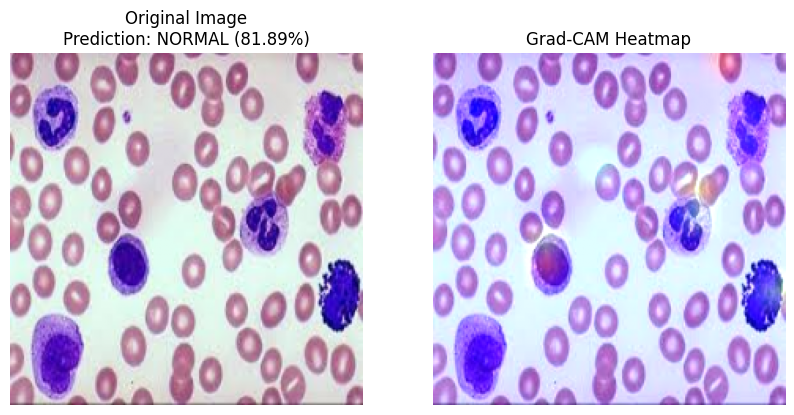

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

--- Analyzing: pre.jpg ---


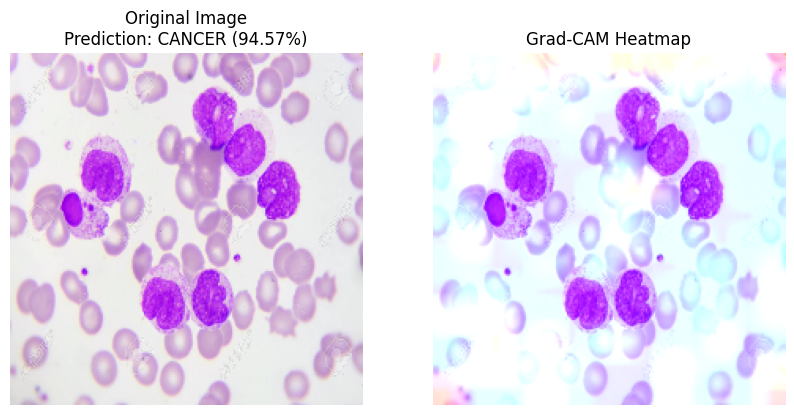

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

--- Analyzing: promyelocytic.jpg ---


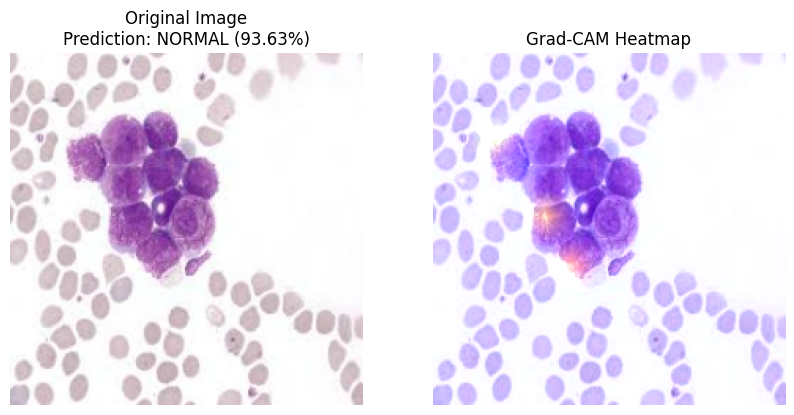

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

--- Analyzing: early.jpg ---


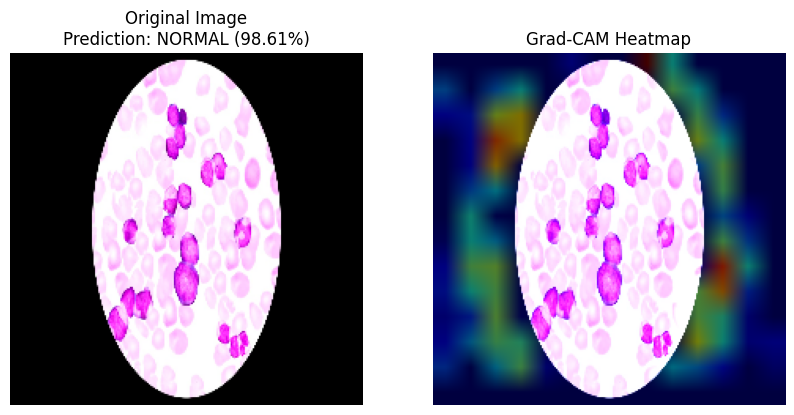

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import cv2
import os
from google.colab import drive

# Mount Google Drive to ensure access
drive.mount('/content/drive', force_remount=True)

# 1. Load your optimized model
model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"

# Add a check to ensure the model file exists before attempting to load
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found at: {model_path}. Please ensure it was saved correctly and Google Drive is mounted.")

model = tf.keras.models.load_model(model_path)

# 2. Dynamically find the last convolutional layer (MobileNetV2 has specific layer structures)
last_conv_layer_name = None
for layer in reversed(model.layers):
    # Adjust for MobileNetV2's common last conv layer names, or check output shape
    # Added hasattr check to prevent AttributeError for layers without output_shape
    if hasattr(layer, 'output_shape') and 'conv' in layer.name and len(layer.output_shape) == 4 and 'add' not in layer.name and 'relu' not in layer.name:
        last_conv_layer_name = layer.name
        break

# Fallback if no specific conv layer found, use a known MobileNetV2 last conv block layer
if last_conv_layer_name is None:
    last_conv_layer_name = 'block_13_expand'

print(f"Targeting layer for Grad-CAM: {last_conv_layer_name}")

# 3. The Grad-CAM Algorithm
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8) # Add epsilon for stability
    return heatmap.numpy()

# 4. Function to display the heatmap over the original image
def display_gradcam(img_path, heatmap, alpha=0.5, class_prediction=""): # Added class_prediction argument
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    superimposed_img = jet_heatmap * alpha + img / 255.0
    superimposed_img = np.clip(superimposed_img, 0, 1)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img / 255.0)
    plt.title(f"Original Image\nPrediction: {class_prediction}") # Show prediction in title
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    plt.show()

# 5. Run it on your Google test images
test_dir = "/content/drive/MyDrive/leukemia-dataset/Unseen_Images"
print("\nGenerating visual explainability maps...")

# Corrected class labels based on previous ImageDataGenerator output (2 classes)
# Assuming 'CANCER' and 'NORMAL' based on dataset structure
# You might need to adjust this if your directories are named differently (e.g., '0' and '1')
# To be absolutely sure, you would check train_data.class_indices from the training cell (dp6i4LviWojZ)
# For now, let's assume alphabetical order for 'CANCER' and 'NORMAL'
# Example: if subfolders are 'CANCER' and 'NORMAL', flow_from_directory might assign {0: 'CANCER', 1: 'NORMAL'}
# If the actual folder names are different, this mapping needs to be adjusted accordingly.
class_labels_map = {0: 'CANCER', 1: 'NORMAL'} # Update based on actual folder names and their assigned indices

for img_name in os.listdir(test_dir):
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(test_dir, img_name)

        # Preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Get model prediction for class_prediction in display function
        predictions = model.predict(img_array)
        predicted_class_idx = np.argmax(predictions)
        predicted_class_label = class_labels_map.get(predicted_class_idx, "Unknown")
        confidence = np.max(predictions) * 100
        class_prediction_text = f"{predicted_class_label} ({confidence:.2f}%)"

        # Generate and display
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=predicted_class_idx)
        print(f"\n--- Analyzing: {img_name} ---")
        display_gradcam(img_path, heatmap, class_prediction=class_prediction_text)

Found 651 images belonging to 2 classes.

Generating predictions for the Confusion Matrix...
21/21 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


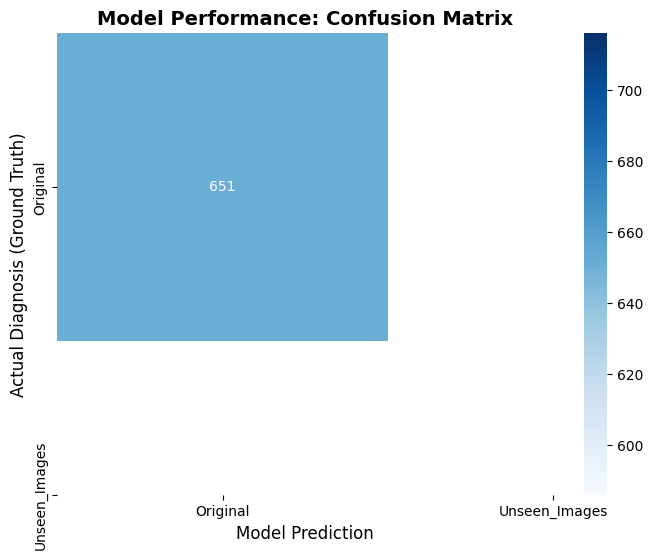


--- Detailed Classification Report ---


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# 1. Load the model
model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.h5"
model = tf.keras.models.load_model(model_path)

# 2. Load the Validation Data (Updated path to remove '/original')
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_data = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/leukemia-dataset/",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 3. Generate predictions
print("\nGenerating predictions for the Confusion Matrix...")
predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Model Performance: Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis (Ground Truth)', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.show()

# 5. Print the Statistical Breakdown
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 649 images belonging to 4 classes.

Generating predictions... This will take a moment.
21/21 ━━━━━━━━━━━━━━━━━━━━ 140s 7s/step


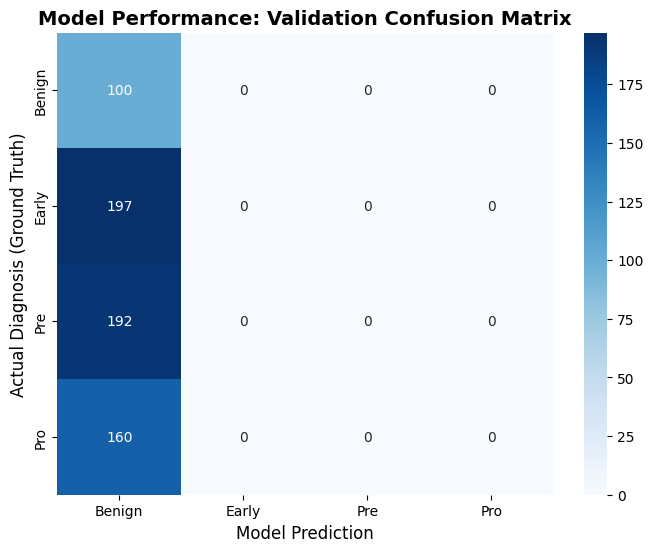


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Benign       0.15      1.00      0.27       100
       Early       0.00      0.00      0.00       197
         Pre       0.00      0.00      0.00       192
         Pro       0.00      0.00      0.00       160

    accuracy                           0.15       649
   macro avg       0.04      0.25      0.07       649
weighted avg       0.02      0.15      0.04       649



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# 1. Exact path to the folder containing early, benign, pre, pro
# (Ensure 'Original' matches the exact capitalization in your Google Drive)
dataset_path = "/content/drive/MyDrive/leukemia-dataset/Original"

# 2. Recreate the EXACT validation generator used during training
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # We MUST include this so it only tests the 20% validation chunk
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',  # Pulls only the validation images
    shuffle=False         # CRITICAL: Keeps predictions and actual images in the exact same order
)

# 3. Generate predictions
print("\nGenerating predictions... This will take a moment.")
predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Model Performance: Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis (Ground Truth)', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.show()

# 5. Print the Statistical Breakdown
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Exact path (Capital 'O' for Original)
dataset_path = "/content/drive/MyDrive/leukemia-dataset/Original"

# 2. Aggressive Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=90,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

print("Loading Training Data...")
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data...")
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 3. Build the Robust Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model
print("\nStarting Training...")
history = model.fit(train_data, validation_data=val_data, epochs=15)

# 5. THE PERMANENT FIX: Save using the native .keras format
model.save("/content/drive/MyDrive/leukemia-dataset/cnn_model.keras")
print("\n✅ Native Keras model saved successfully! Goodbye HDF5 bugs.")

Loading Training Data...
Found 2607 images belonging to 4 classes.

Loading Validation Data...
Found 649 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Training...
Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 753s 9s/step - accuracy: 0.7307 - loss: 0.7126 - val_accuracy: 0.7997 - val_loss: 0.5507
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.8753 - loss: 0.3555 - val_accuracy: 0.8659 - val_loss: 0.3867
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8888 - loss: 0.3097 - val_accuracy: 0.8567 - val_loss: 0.3729
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9053 - loss: 0.2549 - val_accuracy: 0.9014 - val_loss: 0.2828
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9114 - loss: 0.2327 - val_accuracy: 0.9214 - val_loss: 0.2278
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9244 - loss: 0.1970 - val_accuracy: 0.9122 - val_loss: 0.2271
Epoch 7/15
82/82 ━━━━━━━━━━━━━━

Found 649 images belonging to 4 classes.

Generating predictions... This will take a moment.
21/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step


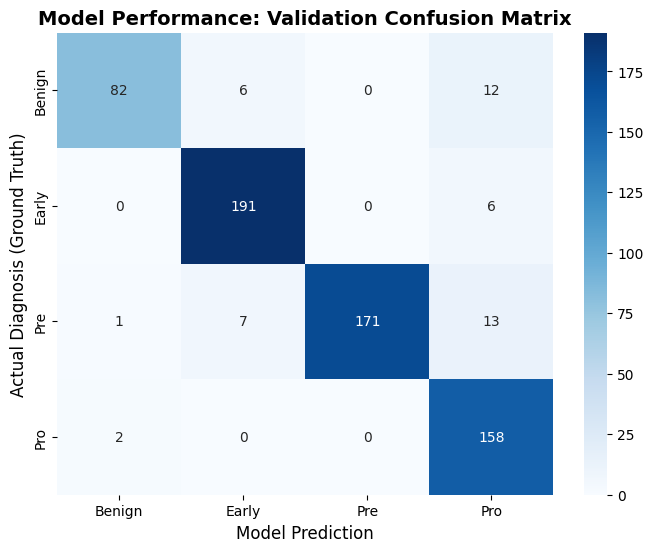


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Benign       0.96      0.82      0.89       100
       Early       0.94      0.97      0.95       197
         Pre       1.00      0.89      0.94       192
         Pro       0.84      0.99      0.91       160

    accuracy                           0.93       649
   macro avg       0.93      0.92      0.92       649
weighted avg       0.93      0.93      0.93       649



In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# 1. Load the new native .keras model
model_path = "/content/drive/MyDrive/leukemia-dataset/cnn_model.keras"
model = tf.keras.models.load_model(model_path)

# 2. Recreate the EXACT validation generator cleanly
dataset_path = "/content/drive/MyDrive/leukemia-dataset/Original"

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# CRITICAL FIX: Reset the generator before predicting to prevent label shifting
val_data.reset()

# 3. Generate predictions
print("\nGenerating predictions... This will take a moment.")
predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Model Performance: Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis (Ground Truth)', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.show()

# 5. Print the Statistical Breakdown
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))